# 06 — Итоговые результаты проекта

## Назначение notebook

Этот notebook **не обучает новые модели и не меняет detector**.
Он собирает frozen-артефакты `03`, `04` и `05` в одну итоговую,
воспроизводимую конкурсную историю:

`forecasting -> forecast surprise -> shock detector -> episodes -> category attribution -> external audit`

## Разделение evaluation layers

Результаты разных временных окон и разных единиц анализа не смешиваются:

- **Jun–Sep 2024** — forecasting challenger benchmark;
- **Oct–Nov 2024** — отдельный later forward benchmark;
- **synthetic TEST** — основной количественный benchmark shock detector;
- **real 2024** — operational interpretation layer;
- **TOP-10 external audit** — ручная post-hoc проверка, а не causal validation.

Главная задача этого notebook — показать итоговые результаты,
их ограничения и сохранить компактные финальные артефакты проекта.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 260)

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "data" / "interim").is_dir():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "interim").is_dir():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Запустите notebook из корня проекта или каталога notebooks/")
CONFIG_FILE = PROJECT_DIR / "configs" / "final_config.yaml"
if CONFIG_FILE.exists():
    print("Project config:", CONFIG_FILE, "(параметры frozen-моделей не переопределяются)")
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
FIG_DIR = PROJECT_DIR / "data" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def first_existing(*paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError("Не найден ни один вариант:\n" + "\n".join(map(str, paths)))

FILES = {
    "forecast_summary": INTERIM_DIR / "forecast_final_summary.csv",
    "forecast_resid_boot": INTERIM_DIR / "forecast_residual_bootstrap.csv",
    "forecast_online_boot": INTERIM_DIR / "forecast_online_bootstrap.csv",
    "shock_test": INTERIM_DIR / "shock_detector_test_summary.csv",
    "shock_recall_delta": first_existing(
        INTERIM_DIR / "shock_detector_event_recall_by_delta.csv",
        INTERIM_DIR / "shock_detector_recall_by_delta.csv",
    ),
    "shock_recall_boot": first_existing(
        INTERIM_DIR / "shock_detector_event_recall_bootstrap.csv",
        INTERIM_DIR / "shock_detector_recall_bootstrap.csv",
    ),
    "real_summary": INTERIM_DIR / "shock_real_cases_summary.csv",
    "episodes": INTERIM_DIR / "shock_episodes_attributed_2024.parquet",
    "top40": INTERIM_DIR / "shock_top40_episodes.csv",
    "evidence": INTERIM_DIR / "shock_external_evidence_completed.csv",
    "manual_audit": INTERIM_DIR / "shock_external_evidence_manual_audit.csv",

    "four_detector": INTERIM_DIR / "shock_detector_four_method_test_comparison.csv",
    "news_events": INTERIM_DIR / "shock_news_events_aligned_top10.csv",
    "news_monthly": INTERIM_DIR / "shock_news_monthly_retrospective_top10.csv",
    "news_audit_quantitative": INTERIM_DIR / "shock_news_alignment_quantitative_top10.csv",
    "news_audit_checks": INTERIM_DIR / "shock_news_alignment_checks_top10.csv",
}

missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Не найдены обязательные артефакты:\n" + "\n".join(missing))

display(pd.DataFrame([
    {"artifact": k, "file": p.name, "exists": p.exists()}
    for k, p in FILES.items()
]))
print("Все обязательные артефакты: OK")


,artifact,file,exists
0,forecast_summary,forecast_final_summary.csv,True
1,forecast_resid_boot,forecast_residual_bootstrap.csv,True
2,forecast_online_boot,forecast_online_bootstrap.csv,True
3,shock_test,shock_detector_test_summary.csv,True
4,shock_recall_delta,shock_detector_event_recall_by_delta.csv,True
5,shock_recall_boot,shock_detector_event_recall_bootstrap.csv,True
6,real_summary,shock_real_cases_summary.csv,True
7,episodes,shock_episodes_attributed_2024.parquet,True
8,top40,shock_top40_episodes.csv,True
9,evidence,shock_external_evidence_completed.csv,True


Все обязательные артефакты: OK


In [2]:
forecast_summary = pd.read_csv(FILES["forecast_summary"])
forecast_resid_boot = pd.read_csv(FILES["forecast_resid_boot"])
forecast_online_boot = pd.read_csv(FILES["forecast_online_boot"], index_col=0)

shock_test = pd.read_csv(FILES["shock_test"])
shock_recall_delta = pd.read_csv(FILES["shock_recall_delta"])
shock_recall_boot = pd.read_csv(FILES["shock_recall_boot"])

real_summary = pd.read_csv(FILES["real_summary"])
episodes = pd.read_parquet(FILES["episodes"])
top40 = pd.read_csv(FILES["top40"])
external_evidence = pd.read_csv(FILES["evidence"])
manual_audit = pd.read_csv(FILES["manual_audit"])

assert len(top40) == 40
assert len(external_evidence) == 10
print("Загрузка итоговых результатов: PASSED")


Загрузка итоговых результатов: PASSED


# 1. Forecasting

`Baseline ensemble` из старых артефактов ниже переименовывается только в presentation layer как **Reference forecasting ensemble**. Это наш внутренний контрольный ансамбль.

Jun–Sep уже использовался в разработке, поэтому residual correction трактуется как challenger benchmark. Oct–Nov — отдельная later-forward проверка.

In [3]:
forecast_summary = forecast_summary.copy()
forecast_summary["model"] = forecast_summary["model"].replace({
    "Baseline ensemble": "Reference forecasting ensemble",
})

def mae(evaluation, model):
    x = forecast_summary[
        (forecast_summary["evaluation"] == evaluation)
        & (forecast_summary["model"] == model)
    ]
    if len(x) != 1:
        raise ValueError(f"Не найден результат: {evaluation} / {model}")
    return float(x.iloc[0]["MAE"])

jun_ref = mae("Jun-Sep benchmark", "Reference forecasting ensemble")
jun_resid = mae("Jun-Sep benchmark", "Cross-sectional residual correction")
fwd_ref = mae("Oct-Nov forward", "Reference forecasting ensemble")
fwd_static = mae("Oct-Nov forward", "Static 45/55")
fwd_online = mae("Oct-Nov forward", "Online adaptive")

forecast_scorecard = pd.DataFrame([
    {"window":"Jun-Sep benchmark","model":"Reference forecasting ensemble","MAE":jun_ref},
    {"window":"Jun-Sep benchmark","model":"Residual correction","MAE":jun_resid},
    {"window":"Oct-Nov forward","model":"Reference forecasting ensemble","MAE":fwd_ref},
    {"window":"Oct-Nov forward","model":"Static 45/55","MAE":fwd_static},
    {"window":"Oct-Nov forward","model":"Online adaptive","MAE":fwd_online},
])
display(forecast_scorecard.round(3))

assert np.isclose(jun_ref, 761.916, atol=0.30)
assert np.isclose(jun_resid, 758.339, atol=0.30)
assert np.isclose(fwd_ref, 880.397, atol=0.40)
assert np.isclose(fwd_static, 858.810, atol=0.40)
assert 834.0 <= fwd_online <= 835.0

print("Forecasting reproducibility: PASSED")


,window,model,MAE
0,Jun-Sep benchmark,Reference forecasting ensemble,761.916
1,Jun-Sep benchmark,Residual correction,758.339
2,Oct-Nov forward,Reference forecasting ensemble,880.397
3,Oct-Nov forward,Static 45/55,858.810
4,Oct-Nov forward,Online adaptive,834.331


Forecasting reproducibility: PASSED


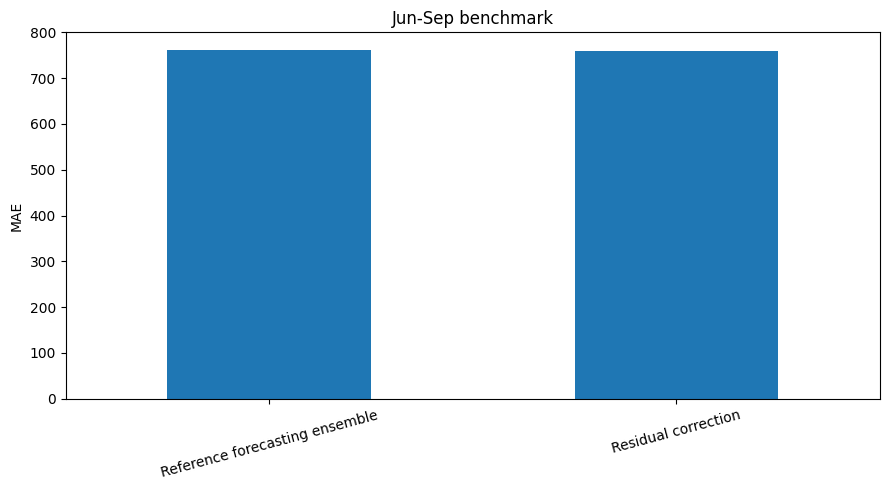

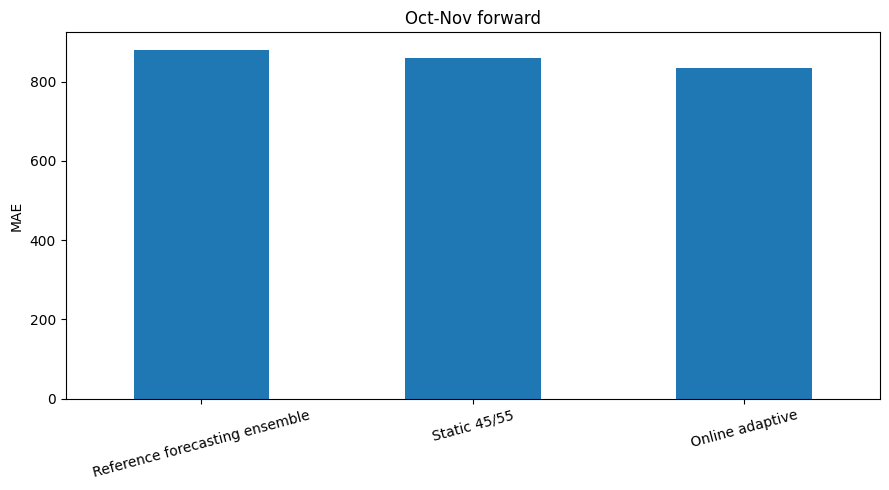

Jun-Sep bootstrap:


,mean_gain,ci_2.5,ci_97.5,P(gain>0),share_series_improved
0,3.577,2.764,4.411,1.0,0.597



Oct-Nov bootstrap:


,mean_gain,ci_2.5,ci_97.5,P(gain>0)
vs_static,24.479,18.885,30.209,1.0
vs_baseline,46.066,33.551,59.430,1.0


In [4]:
for evaluation, filename in [
    ("Jun-Sep benchmark", "06_forecast_jun_sep.png"),
    ("Oct-Nov forward", "06_forecast_forward.png"),
]:
    part = forecast_scorecard[forecast_scorecard["window"] == evaluation].set_index("model")
    ax = part["MAE"].plot(kind="bar", figsize=(9,5))
    ax.set_title(evaluation)
    ax.set_xlabel("")
    ax.set_ylabel("MAE")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

print("Jun-Sep bootstrap:")
display(forecast_resid_boot.round(3))
print("\nOct-Nov bootstrap:")
display(forecast_online_boot.round(3))


## 1A. Единый forecasting benchmark, включая Prophet

Сравнение производится **только на одинаковых 24 192 ячейках** (`series_id`, `origin`, `h`, `target_period`) из notebook `01`. Это исторический benchmark, не скрытый конкурсный TEST. Результаты `03` далее показываются отдельно: Jun–Sep challenger и Oct–Nov forward.


In [5]:
# Notebook 01 — единый forecasting benchmark с Prophet.
# Загрузка зафиксированного машиночитаемого результата без fallback на ручные числа.
prophet_file = INTERIM_DIR / "baseline_multihorizon_summary.csv"
if not prophet_file.is_file():
    raise FileNotFoundError(
        f"Отсутствует итоговый benchmark notebook 01: {prophet_file}. "
        "Сначала выполните notebook 01 и сохраните его итоговую таблицу."
    )
prophet_table = pd.read_csv(prophet_file)
required = {"model", "MAE", "n_predictions"}
assert required.issubset(prophet_table.columns), required - set(prophet_table.columns)
assert prophet_table["model"].is_unique
assert prophet_table["model"].notna().all()
assert set(["prophet", "ensemble_mean"]).issubset(set(prophet_table["model"].str.lower()))
assert pd.to_numeric(prophet_table["n_predictions"], errors="raise").eq(24192).all()
assert np.isfinite(pd.to_numeric(prophet_table["MAE"], errors="raise")).all()
prophet_source_label = prophet_file.name
prophet_mae = float(prophet_table.loc[prophet_table["model"].str.lower().eq("prophet"), "MAE"].iloc[0])
reference01_mae = float(prophet_table.loc[prophet_table["model"].str.lower().eq("ensemble_mean"), "MAE"].iloc[0])
assert np.isclose(reference01_mae, 761.9164, rtol=0, atol=0.01)
assert np.isclose(prophet_mae, 1428.0021, rtol=0, atol=0.01)
prophet_gain_pct = 100 * (prophet_mae - reference01_mae) / prophet_mae
print("Source:", prophet_source_label)
display(prophet_table.sort_values("MAE").round(4))
print(f"Reference ensemble vs Prophet: {prophet_gain_pct:.2f}% lower MAE")
print("Unified Prophet benchmark: PASSED")


Source: baseline_multihorizon_summary.csv


,model,MAE,R2,MAE_h1,MAE_h2,MAE_h3,n_predictions
0,ensemble_mean,761.9164,0.9913,660.9315,736.0205,888.7973,24192
1,chronos_relative,885.7636,0.9883,745.1180,869.0056,1043.1672,24192
2,ets_relative,925.7915,0.9849,775.1356,905.8818,1096.3572,24192
3,factor_anchor,939.2651,0.9839,756.9836,912.0494,1148.7622,24192
4,seasonal_growth,995.0258,0.9871,830.1138,990.2489,1164.7147,24192
5,prophet,1428.0021,0.9711,918.8340,1349.1711,2016.0012,24192


Reference ensemble vs Prophet: 46.64% lower MAE
Unified Prophet benchmark: PASSED


### Вывод по forecasting — итоговое сравнение моделей

На данном этапе выполнено сравнение методов прогнозирования муниципальных потребительских расходов СберИндекса на едином multi-horizon протоколе.

#### 1. Сравнение с Prophet и базовыми моделями

Все модели оценивались на одинаковых условиях:

- **2 016 муниципальных временных рядов**;
- **4 forecast origins** — июнь–сентябрь 2024 года;
- **3 горизонта прогнозирования** — 1, 2 и 3 месяца;
- **24 192 прогнозных значения на модель**;
- единая метрика качества — MAE.

| Модель | MAE |
|---|---:|
| **Reference forecasting ensemble** | **761.916** |
| Chronos relative | 885.764 |
| ETS relative | 925.792 |
| Factor anchor | 939.265 |
| Seasonal Growth | 995.026 |
| Prophet | 1428.002 |

**Reference forecasting ensemble снизил MAE относительно Prophet на 46.64%.**

Результат подтверждён на одинаковом наборе прогнозных ячеек. Это обеспечивает прямую сопоставимость моделей в рамках выбранного исторического протокола.

Ансамбль объединяет три взаимодополняющих подхода: Chronos, ETS и Seasonal Growth с равными весами.

#### 2. Финальный challenger — Jun–Sep 2024

Поверх сильного Reference forecasting ensemble протестирована консервативная cross-sectional residual correction.

| Модель | MAE |
|---|---:|
| Reference forecasting ensemble | 761.916 |
| **Cross-sectional residual correction** | **758.339** |

Абсолютное улучшение составляет **3.577 MAE**, относительное — **0.47%**.

Полученный эффект следует трактовать как небольшое дополнительное улучшение сильного baseline, а не как принципиально новый уровень точности.

#### 3. Независимая поздняя forward-проверка — Oct–Nov 2024

На отдельном более позднем временном окне выполнено сравнение трёх стратегий прогнозирования.

| Модель | MAE |
|---|---:|
| Reference forecasting ensemble | 880.397 |
| Static 45/55 | 858.810 |
| **Online adaptive ensemble** | **834.331** |

Online adaptive ensemble показал:

- улучшение на **46.066 MAE (5.23%)** относительно Reference ensemble;
- улучшение на **24.479 MAE (2.85%)** относительно Static 45/55.

Преимущество online adaptive подтверждено bootstrap-анализом по муниципальным временным рядам.

Это свидетельствует о том, что адаптивное перераспределение весов экспертов по доступным историческим ошибкам может быть полезнее фиксированной комбинации при изменении временного режима.

#### 4. Методологическая интерпретация

Результаты Jun–Sep и Oct–Nov относятся к разным временным окнам и **не сравниваются напрямую по абсолютным значениям MAE**.

- Jun–Sep — основной исторический multi-horizon benchmark и проверка residual challenger.
- Oct–Nov — отдельная поздняя forward-проверка адаптивного ансамбля.
- Prophet сравнивается с Reference ensemble на идентичных прогнозных ячейках Jun–Sep.

Результаты не следует интерпретировать как гарантию аналогичного улучшения на любых будущих данных.

#### Итог

Forecasting-блок Shock Radar включает классические статистические методы, фундаментальную модель временных рядов **Chronos-Bolt**, ансамблирование и консервативную адаптивную коррекцию.

**Главный результат:** Reference ensemble превосходит Prophet на **46.64% по MAE** в едином benchmark; residual correction дополнительно улучшает качество до **758.339 MAE**, а Online adaptive достигает **834.331 MAE** на отдельной поздней forward-проверке.

Таким образом, forecasting-часть обеспечивает воспроизводимую основу для расчёта ожидаемой динамики расходов и дальнейшего обнаружения структурных изменений через forecast surprise.

# 2. Shock detector — frozen synthetic TEST

Основная единица оценки — synthetic **event**. Event Recall и delay не смешиваются с month-level precision/recall/F1.

Reference cross-sectional detector — простой внутренний контроль. Size-aware forecast-surprise detector — итоговый detector.

In [6]:
shock_test = shock_test.copy()
shock_test["method"] = shock_test["method"].replace({
    "Cross-sectional baseline": "Reference cross-sectional detector",
    "Size-aware surprise": "Size-aware forecast-surprise detector",
})

cols = [
    "method","event_recall","mean_delay","share_delay0","false_alarms_100",
    "n_events","events_found","month_precision","month_recall","month_f1"
]
detector_table = shock_test[cols].copy()
display(detector_table.round(4))

def detrow(name):
    x = detector_table[detector_table["method"] == name]
    if len(x) != 1:
        raise ValueError(name)
    return x.iloc[0]

det_ref = detrow("Reference cross-sectional detector")
det_size = detrow("Size-aware forecast-surprise detector")

assert np.isclose(det_ref["event_recall"], 0.5623, atol=0.002)
assert np.isclose(det_size["event_recall"], 0.6571, atol=0.002)
assert int(det_ref["events_found"]) == 2834
assert int(det_size["events_found"]) == 3312

print("Shock detector reproducibility: PASSED")


,method,event_recall,mean_delay,share_delay0,false_alarms_100,n_events,events_found,month_precision,month_recall,month_f1
0,Reference cross-sectional detector,0.5623,0.0515,0.9633,3.2238,5040,2834,0.5516,0.1263,0.2056
1,Size-aware forecast-surprise detector,0.6571,0.0851,0.9333,3.4483,5040,3312,0.7026,0.2381,0.3557


Shock detector reproducibility: PASSED


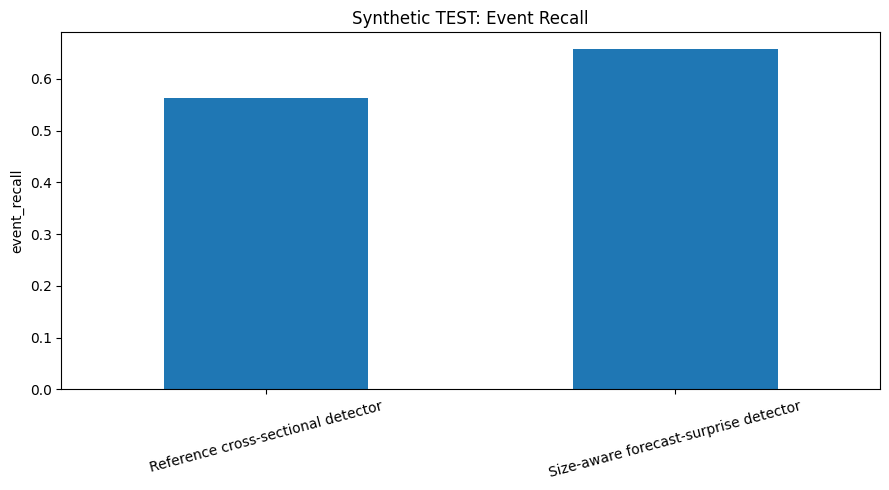

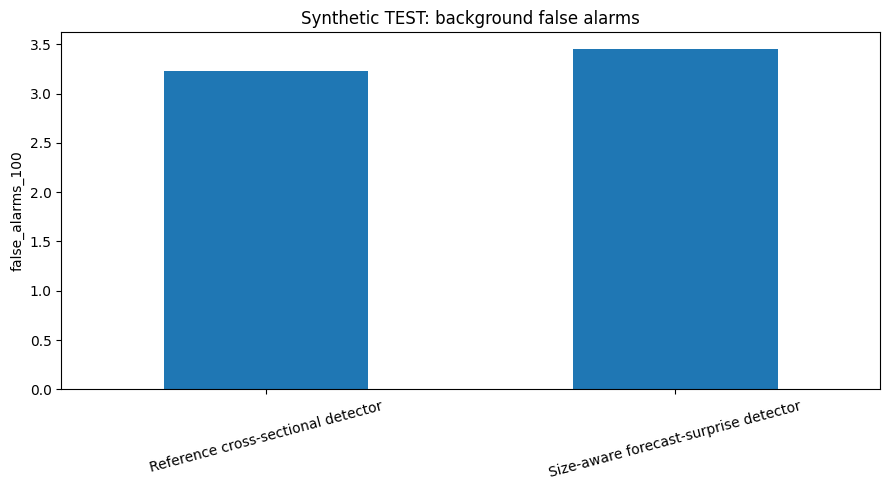

In [7]:
for metric, title, filename in [
    ("event_recall", "Synthetic TEST: Event Recall", "06_detector_event_recall.png"),
    ("false_alarms_100", "Synthetic TEST: background false alarms", "06_detector_false_alarms.png"),
]:
    part = detector_table[["method", metric]].set_index("method")
    ax = part[metric].plot(kind="bar", figsize=(9,5))
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


## 2A. Четыре метода structural change detection

CUSUM и Page–Hinkley откалиброваны на DEV; здесь читается независимый TEST из `04`. Size-aware выбран по **Event Recall при сопоставимом FAR**, но CUSUM превосходит его по month-level F1; победа по всем метрикам не заявляется.


,method,event_recall,mean_delay,share_delay0,false_alarms_100,n_events,events_found,n_alarms,background_alarms,event_months,correct_event_alarms,other_correct_event_alarms,wrong_direction_event_alarms,month_precision,month_recall,month_f1
0,Cross-sectional baseline,0.5623,0.0515,0.9633,3.2238,5040,2834,5680,2125,24804,3133,299,422,0.5516,0.1263,0.2056
1,Size-aware surprise,0.6571,0.0851,0.9333,3.4483,5040,3312,8406,2273,24804,5906,2594,227,0.7026,0.2381,0.3557
2,CUSUM,0.5075,0.5301,0.5551,3.2238,5040,2558,12642,2125,24804,10363,7805,154,0.8197,0.4178,0.5535
3,Page-Hinkley,0.4476,0.2983,0.7332,3.4468,5040,2256,11485,2272,24804,5980,3724,3233,0.5207,0.2411,0.3296


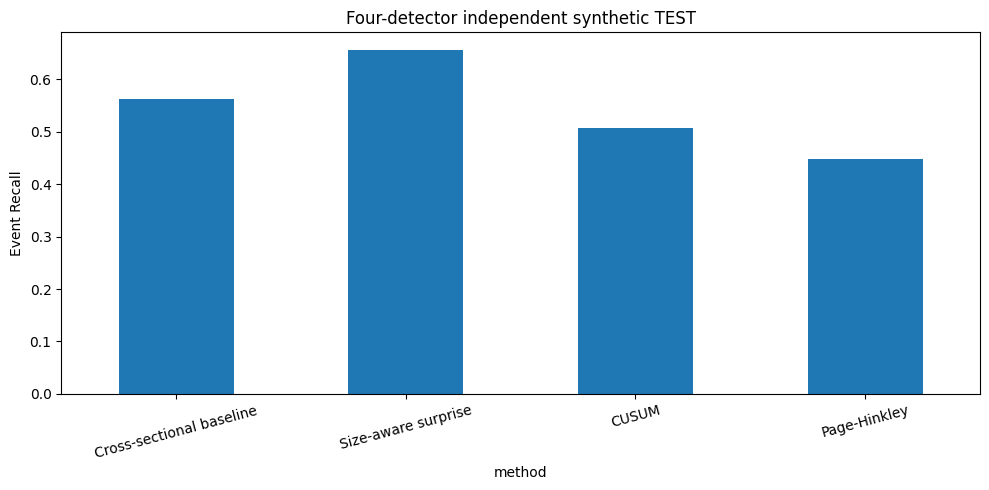

Four-detector final comparison: PASSED


In [8]:
four_detector = pd.read_csv(FILES["four_detector"])
required = {"method", "event_recall", "mean_delay", "share_delay0", "false_alarms_100", "month_f1", "n_events", "events_found"}
assert required.issubset(four_detector.columns), required - set(four_detector.columns)
assert set(four_detector["method"]) == {
    "Cross-sectional baseline", "Size-aware surprise", "CUSUM", "Page-Hinkley"
}
assert four_detector["n_events"].eq(5040).all()
assert four_detector["method"].is_unique
assert np.isclose(float(four_detector.loc[four_detector.method.eq("Size-aware surprise"), "event_recall"].iloc[0]), 0.6571, atol=0.002)
assert float(four_detector.loc[four_detector.method.eq("CUSUM"), "month_f1"].iloc[0]) > float(four_detector.loc[four_detector.method.eq("Size-aware surprise"), "month_f1"].iloc[0])
display(four_detector.round(4))
ax = four_detector.set_index("method")["event_recall"].plot(kind="bar", figsize=(10,5))
ax.set_ylabel("Event Recall")
ax.set_title("Four-detector independent synthetic TEST")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_four_detector_event_recall.png", dpi=160, bbox_inches="tight")
plt.show()
print("Four-detector final comparison: PASSED")


method,Reference cross-sectional detector,Size-aware forecast-surprise detector
delta,,
-0.20,0.9734,0.9987
-0.10,0.6693,0.7761
-0.05,0.1590,0.2503
0.05,0.1314,0.2360
0.10,0.5123,0.7099
0.20,0.9469,0.9908


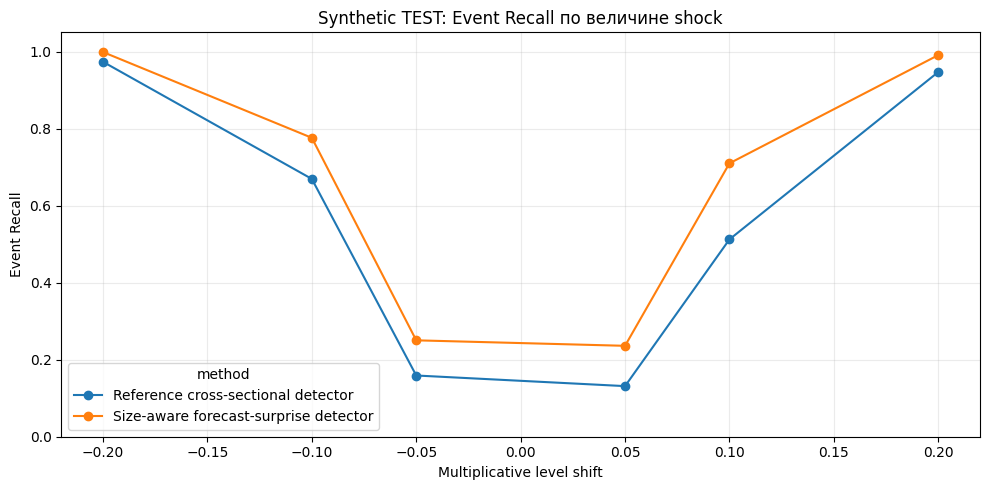

,paired_mean_recall_gain,ci_2.5,ci_97.5,P(gain>0)
0,0.0948,0.0792,0.1052,1.0


In [9]:
shock_recall_delta = shock_recall_delta.copy()
shock_recall_delta["method"] = shock_recall_delta["method"].replace({
    "Cross-sectional baseline": "Reference cross-sectional detector",
    "Size-aware surprise": "Size-aware forecast-surprise detector",
})

recall_col = "event_recall" if "event_recall" in shock_recall_delta.columns else "recall"

recall_by_delta = shock_recall_delta.pivot(
    index="delta",
    columns="method",
    values=recall_col,
).sort_index()

display(recall_by_delta.round(4))

ax = recall_by_delta.plot(marker="o", figsize=(10,5))
ax.set_title("Synthetic TEST: Event Recall по величине shock")
ax.set_xlabel("Multiplicative level shift")
ax.set_ylabel("Event Recall")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_detector_recall_by_delta.png", dpi=160, bbox_inches="tight")
plt.show()

display(shock_recall_boot.round(4))

boot = shock_recall_boot.iloc[0]
boot_gain = float(boot["paired_mean_recall_gain"])
boot_low = float(boot["ci_2.5"])
boot_high = float(boot["ci_97.5"])
boot_prob = float(boot["P(gain>0)"])

assert boot_low > 0


### Вывод по structural change detection

В рамках Shock Radar проведено сравнение четырёх методов обнаружения структурных изменений муниципальных потребительских расходов:

1. **Reference cross-sectional detector** — контрольный метод на основе отклонения от динамики панели муниципалитетов.
2. **Size-aware forecast-surprise detector** — предлагаемый метод, учитывающий ошибку прогноза и масштаб муниципального ряда.
3. **CUSUM** — классический последовательный метод накопления отклонений.
4. **Page–Hinkley** — классический метод выявления устойчивых изменений среднего уровня.

Все методы оценены на едином независимом **synthetic TEST из 5 040 структурных событий**. Для классических алгоритмов пороги настраивались только на DEV и фиксировались до TEST.

## 1. Сравнение четырёх методов

| Метод | Event Recall | Найдено событий | FAR/100 | Mean Delay | Month F1 |
|---|---:|---:|---:|---:|---:|
| Cross-sectional baseline | 56.23% | 2 834 | 3.224 | **0.052** | 20.56% |
| **Size-aware surprise** | **65.71%** | **3 312** | 3.448 | 0.085 | 35.57% |
| CUSUM | 50.75% | 2 558 | **3.224** | 0.530 | **55.35%** |
| Page–Hinkley | 44.76% | 2 256 | 3.447 | 0.298 | 32.96% |

**Size-aware forecast-surprise detector достигает наибольшего Event Recall — 65.71%.**

При этом CUSUM демонстрирует лучший результат по Month F1 — 55.35%. Это показывает, что преимущество зависит от целевой метрики, и ни один из методов не доминирует по всем характеристикам одновременно.

## 2. Преимущество Size-aware по обнаружению событий

В сравнении с Reference cross-sectional detector:

- Event Recall увеличился с **56.23% до 65.71%**;
- абсолютный прирост составил **+9.48 процентного пункта**;
- относительное улучшение составило **+16.87%**;
- дополнительно обнаружено **478 событий**.

При этом Size-aware обнаруживает 93.33% найденных им событий непосредственно в месяц их начала, а средняя задержка среди найденных событий составляет 0.085 месяца.

Эти показатели свидетельствуют о высокой оперативности обнаружения в пределах заданного synthetic-протокола.

## 3. Устойчивость результата

Для основной пары детекторов проведён cluster bootstrap по муниципальным временным рядам.

Получены:

| Показатель | Значение |
|---|---:|
| Средний прирост Event Recall | +9.48 п.п. |
| 95% доверительный интервал | **[+7.92; +10.52] п.п.** |
| Доля bootstrap-повторов с положительным приростом | 1.000 |

Доверительный интервал полностью находится выше нуля, что подтверждает устойчивость преимущества Size-aware над Reference cross-sectional detector в рамках выбранного synthetic TEST.

Bootstrap не следует интерпретировать как гарантию превосходства на реальных экономических событиях.

## 4. Цена повышения чувствительности

Более высокий Event Recall сопровождается умеренным ростом фоновых ложных тревог:

- Reference: **3.224** тревоги на 100 фоновых ряд-месяцев;
- Size-aware: **3.448** тревоги на 100 фоновых ряд-месяцев;
- разница: **+0.225** тревоги на 100 фоновых ряд-месяцев.

Задержка первого обнаружения среди найденных событий также немного увеличивается: с 0.052 до 0.085 месяца.

Таким образом, повышение чувствительности достигается ценой ограниченного увеличения фоновой нагрузки и небольшой дополнительной задержки.

## 5. Различия между event-level и month-level оценками

Важный результат сравнительного эксперимента — различие между качеством обнаружения событий и качеством помесячной разметки.

**Event Recall** показывает, какая доля структурных событий была обнаружена в допустимом временном окне.

**Month F1** оценивает согласованность помесячных сигналов с разметкой активных месяцев события.

CUSUM показал наибольший Month F1 (**55.35%**), но уступил Size-aware по Event Recall (**50.75% против 65.71%**) и средней задержке обнаружения (**0.530 против 0.085 месяца**).

Следовательно, CUSUM лучше соответствует задаче помесячного сопровождения изменённого режима по метрике F1, тогда как Size-aware эффективнее обнаруживает больше отдельных событий в заданном окне.

## 6. Выбор финального метода

Для итоговой системы **Shock Radar** выбран Size-aware forecast-surprise detector.

Выбор определяется приоритетами задачи:

- максимизация доли обнаруженных структурных событий;
- контроль фоновых ложных тревог;
- небольшая задержка обнаружения;
- возможность интерпретировать сигналы через отклонение от ожидаемой динамики расходов.

Size-aware показал наибольший Event Recall среди четырёх сравниваемых методов при сопоставимом уровне фоновых ложных тревог.

При этом преимущество CUSUM по Month F1 сохраняется как важный результат исследования и не скрывается при выборе финальной архитектуры.

## 7. Ограничения

Synthetic TEST содержит контролируемые структурные изменения с известными параметрами и моментами начала.

Поэтому полученные метрики характеризуют способность методов обнаруживать заданные искусственные изменения, но не подтверждают экономическую природу реальных аномалий.

Фоновая частота ложных тревог на synthetic TEST также не является оценкой доли ложных экономических сигналов в реальных данных.

---

## Итог

Проведённое сравнение показывает, что **Size-aware forecast-surprise detector является предпочтительным методом для event-oriented задачи Shock Radar**.

Основной результат — увеличение Event Recall с **56.23% до 65.71%**, или на **+9.48 п.п.**, относительно reference detector при умеренном изменении фоновой частоты ложных тревог.

Дополнительное сравнение с CUSUM и Page–Hinkley подтверждает, что Size-aware лидирует по охвату обнаруженных событий, тогда как CUSUM обладает преимуществом по Month F1.

Это обосновывает выбор финального детектора на основании **заранее определённой целевой задачи**, а не утверждения универсального превосходства по всем метрикам.

# 3. Реальные shock episodes 2024

Operational alarms — кандидаты для анализа, а не автоматически подтверждённые события.

Категориальная атрибуция в `05` выполнялась только в `peak_month` общего episode.

,metric,value
0,Monthly signals,975
1,Series with signals,546
2,Shock episodes,826
3,Safe category-alignment episodes,776
4,Episodes with main driver,639



Профили всех episodes:


,profile_type,n_episodes,share_pct
0,sectoral,474,57.38
1,broad_local,165,19.98
2,weak/mixed,137,16.59
3,unavailable,50,6.05



Главные статистические драйверы:


,main_driver,n_episodes
0,Продовольствие,218
1,Маркетплейсы,161
2,Транспорт,94
3,Общественное питание,88
4,Здоровье,78


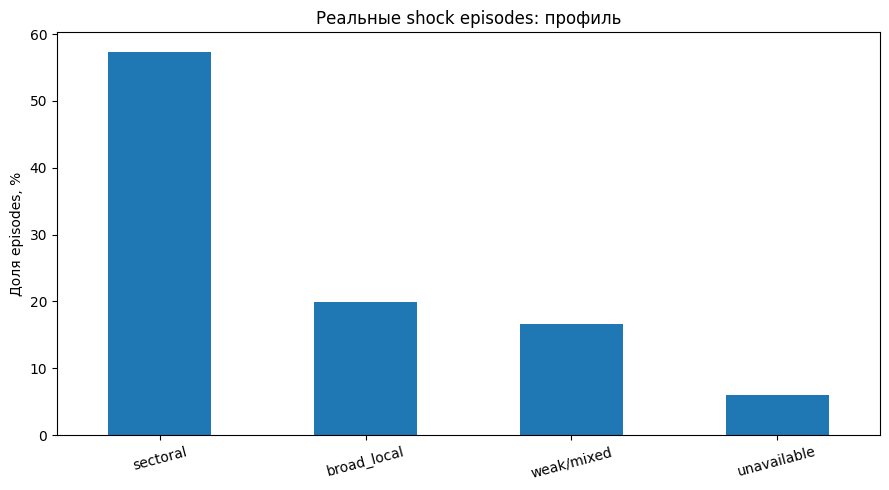

In [10]:
assert {"metric", "value"}.issubset(real_summary.columns)
assert real_summary["metric"].notna().all() and real_summary["metric"].is_unique
real_map = pd.to_numeric(
    real_summary.set_index("metric")["value"], errors="raise"
).to_dict()

for k, expected in {
    "monthly_signals":975,
    "series_with_signals":546,
    "shock_episodes":826,
    "safe_category_alignment_episodes":776,
    "episodes_with_main_driver":639,
}.items():
    assert int(real_map[k]) == expected

real_scorecard = pd.DataFrame([
    {"metric":"Monthly signals","value":int(real_map["monthly_signals"])},
    {"metric":"Series with signals","value":int(real_map["series_with_signals"])},
    {"metric":"Shock episodes","value":int(real_map["shock_episodes"])},
    {"metric":"Safe category-alignment episodes","value":int(real_map["safe_category_alignment_episodes"])},
    {"metric":"Episodes with main driver","value":int(real_map["episodes_with_main_driver"])},
])
display(real_scorecard)

profile_summary = episodes["profile_type"].value_counts().rename_axis("profile_type").reset_index(name="n_episodes")
profile_summary["share_pct"] = 100 * profile_summary["n_episodes"] / len(episodes)

driver_summary = (
    episodes[episodes["main_driver"].notna()]["main_driver"]
    .value_counts()
    .rename_axis("main_driver")
    .reset_index(name="n_episodes")
)

print("\nПрофили всех episodes:")
display(profile_summary.round(2))
print("\nГлавные статистические драйверы:")
display(driver_summary)

ax = profile_summary.set_index("profile_type")["share_pct"].plot(kind="bar", figsize=(9,5))
ax.set_title("Реальные shock episodes: профиль")
ax.set_xlabel("")
ax.set_ylabel("Доля episodes, %")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_episode_profiles.png", dpi=160, bbox_inches="tight")
plt.show()


In [11]:
top40_profile = top40["profile_type"].value_counts().rename_axis("profile_type").reset_index(name="n")
top40_driver = (
    top40[top40["main_driver"].notna()]["main_driver"]
    .value_counts()
    .rename_axis("main_driver")
    .reset_index(name="n")
)

print("TOP-40 profile:")
display(top40_profile)
print("\nTOP-40 drivers:")
display(top40_driver)

print("\nTOP-15:")
with pd.option_context("display.max_colwidth",80,"display.width",300,"display.max_columns",None):
    display(
        top40[
            ["priority_rank","mo","start_month","end_month","direction",
             "n_signal_months","max_score_ratio","max_abs_surprise_pct",
             "profile_type","n_interpretable_categories","main_driver"]
        ].head(15).round(3)
    )


TOP-40 profile:


,profile_type,n
0,broad_local,28
1,sectoral,10
2,weak/mixed,2



TOP-40 drivers:


,main_driver,n
0,Продовольствие,17
1,Маркетплейсы,8
2,Общественное питание,6
3,Транспорт,4
4,Здоровье,3



TOP-15:


,priority_rank,mo,start_month,end_month,direction,n_signal_months,max_score_ratio,max_abs_surprise_pct,profile_type,n_interpretable_categories,main_driver
0,1,внутригородская территория города федерального значения поселение Киевский,2024-04-01,2024-08-01,positive,5,4.835,37.152,broad_local,5,Продовольствие
1,2,городской округ Мамоновский,2024-07-01,2024-09-01,positive,3,3.046,28.946,broad_local,5,Маркетплейсы
2,3,Старошайговский муниципальный район,2024-04-01,2024-05-01,positive,2,2.963,55.751,sectoral,2,Продовольствие
3,4,внутригородская территория города федерального значения поселение Кокошкино,2024-05-01,2024-09-01,positive,5,2.614,18.804,broad_local,5,Транспорт
4,5,городской округ Макаровский,2024-10-01,2024-11-01,positive,2,3.936,23.174,broad_local,4,Продовольствие
5,6,внутригородская территория города федерального значения поселение Щаповское,2024-04-01,2024-06-01,positive,3,2.057,23.082,broad_local,5,Маркетплейсы
6,7,городской округ город Коряжма,2024-11-01,2024-12-01,positive,2,4.147,21.590,broad_local,5,Продовольствие
7,8,Бай-Тайгинский муниципальный район,2024-10-01,2024-11-01,negative,2,2.664,19.162,sectoral,2,Здоровье
8,9,городской округ город Волгореченск,2024-05-01,2024-07-01,negative,3,2.560,15.521,broad_local,3,Продовольствие
9,10,Котласский муниципальный округ,2024-07-01,2024-08-01,negative,2,3.281,17.360,broad_local,4,Маркетплейсы


### Вывод по реальным shock episodes 2024 года

После применения замороженного detector к реальным данным 2024 года получено:

- **975 месячных сигналов**;
- сигналы обнаружены в **546 муниципальных рядах**;
- после объединения соседних сигналов одного направления сформировано **826 shock episodes**;
- для **776 episodes** доступно безопасное межкатегориальное сопоставление;
- в **639 episodes** обнаружена хотя бы одна сильная согласованная категория, позволяющая определить статистический `main_driver`.

Таким образом, переход от отдельных месячных alarms к episodes уменьшает фрагментацию результата и позволяет рассматривать продолжительный сдвиг как единый статистический эпизод.

#### Структура всех 826 episodes

По категориальному профилю episodes распределяются следующим образом:

- `sectoral` — **474 episodes (57.38%)**;
- `broad_local` — **165 (19.98%)**;
- `weak/mixed` — **137 (16.59%)**;
- `unavailable` — **50 (6.05%)**.

Большинство обнаруженных episodes имеют **sectoral** характер: сильное согласованное отклонение наблюдается только в одной или двух категориях.

Около **20%** episodes имеют `broad_local` профиль — сильный однонаправленный сигнал одновременно присутствует как минимум в трёх компонентных категориях. Такие случаи особенно интересны для дальнейшего анализа, поскольку аномалия не ограничивается одной категорией расходов.

`weak/mixed` episodes имеют статистический сигнал в агрегированном ряду, но на `peak_month` не демонстрируют достаточно сильной согласованной структуры в компонентных категориях.

Для `unavailable` cases межкатегориальная атрибуция сознательно не выполняется из-за неоднозначного географического сопоставления.

#### Основные статистические драйверы

Среди **639 episodes**, для которых удалось определить `main_driver`, наиболее часто встречаются:

- **Продовольствие — 218 episodes**;
- **Маркетплейсы — 161**;
- **Транспорт — 94**;
- **Общественное питание — 88**;
- **Здоровье — 78**.

Продовольствие и Маркетплейсы вместе являются главными статистическими драйверами более чем половины интерпретируемых episodes.

При этом `main_driver` не означает денежный вклад категории и не является доказанной причиной shock. Это категория с наиболее сильным согласованным статистическим отклонением в `peak_month`.

### TOP-40 наиболее приоритетных episodes

Среди TOP-40 по заранее определённому `priority_rank` структура заметно отличается от общей выборки:

- `broad_local` — **28 из 40 (70%)**;
- `sectoral` — **10 из 40 (25%)**;
- `weak/mixed` — **2 из 40 (5%)**.

Для сравнения, среди всех 826 episodes `broad_local` составляет только **19.98%**.

Следовательно, среди наиболее сильных и продолжительных статистических аномалий существенно чаще встречаются случаи, в которых изменение одновременно проявляется в нескольких категориях расходов.

Важно, что `profile_type` не используется при построении `priority_rank`. Рейтинг основан на силе detector score, величине surprise и продолжительности episode. Поэтому высокая доля `broad_local` в TOP-40 является результатом последующей категориальной диагностики, а не заранее заложенным критерием отбора.

#### Драйверы TOP-40

Среди TOP-40 наиболее часто встречаются:

- Продовольствие — **17 cases**;
- Маркетплейсы — **8**;
- Общественное питание — **6**;
- Транспорт — **4**;
- Здоровье — **3**.

У двух `weak/mixed` episodes сильный `main_driver` отсутствует.

### Что видно в TOP-15

TOP-15 содержит как продолжительные `broad_local` episodes, так и более локальные `sectoral` случаи.

Например:

- Киевский — положительный `broad_local` episode продолжительностью **5 месяцев**;
- Кокошкино — положительный `broad_local` episode продолжительностью **5 месяцев**;
- Щаповское — положительный `broad_local` episode продолжительностью **3 месяца**;
- Старошайговский район — сильный, но `sectoral` episode;
- Бай-Тайгинский район — отрицательный `sectoral` episode;
- Волгореченск и Котласский округ — отрицательные `broad_local` episodes.

Максимальный абсолютный surprise среди показанных TOP-15 наблюдается у Старошайговского района — около **55.75%**, однако сам episode имеет `sectoral` профиль. Это ещё раз показывает, что величина агрегированного shock и ширина его распространения по категориям являются разными характеристиками.

### Общий вывод

Реальный operational слой не просто выдаёт список месячных тревог.

Он последовательно переводит:

`monthly alarm -> shock episode -> category profile -> statistical driver -> priority rank`

Это позволяет отделять:

- краткие и локальные отклонения;
- устойчивые sectoral shifts;
- широкие `broad_local` изменения;
- случаи, где категориальная интерпретация ненадёжна.

При этом все 826 episodes остаются **статистическими кандидатами**, а не подтверждёнными экономическими событиями. Причинная интерпретация требует отдельной внешней проверки, которая выполняется далее для заранее зафиксированного TOP-10.

# 4. External audit TOP-10

Первые 10 cases были зафиксированы по `priority_rank` до просмотра источников.

`strong_match` означает сильное структурное/временное совпадение, но не causal proof.

,evidence_status,n_cases,share_pct
0,strong_match,3,30.0
1,possible_match,3,30.0
2,external_event_without_clear_link,2,20.0
3,no_clear_explanation,2,20.0


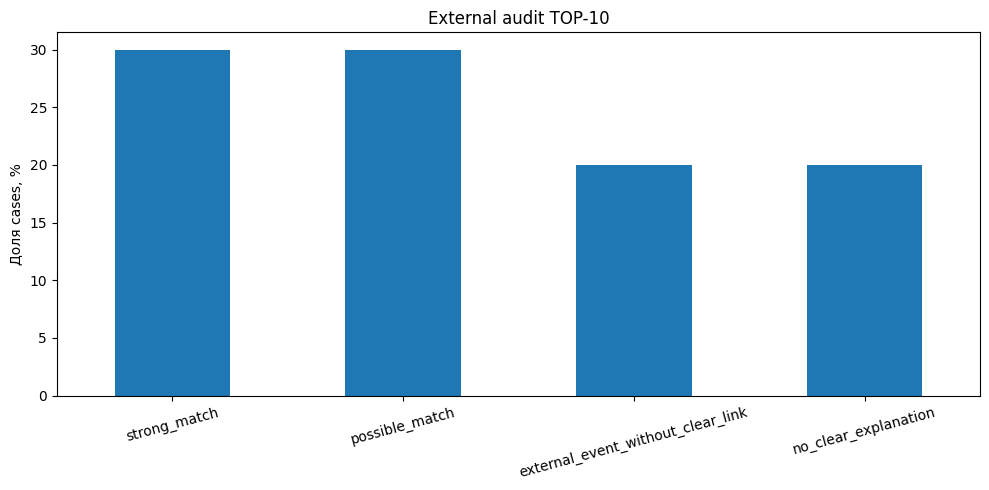

,priority_rank,mo,audit_group,direction,profile_type,main_driver,event_type,external_event_date,evidence_status,source_class,source_name
0,1,внутригородская территория города федерального значения поселение Киевский,A_structural,positive,broad_local,Продовольствие,administrative_reform,2024-05-08,strong_match,official_municipal,Муниципальный округ Бекасово — историческая справка
1,2,городской округ Мамоновский,B_local_economic,positive,broad_local,Маркетплейсы,city_event,2024-07-20,external_event_without_clear_link,local_press,Большая районка — День города Мамоново
2,3,Старошайговский муниципальный район,C_unresolved,positive,sectoral,Продовольствие,unresolved,NaN,no_clear_explanation,NaN,NaN
3,4,внутригородская территория города федерального значения поселение Кокошкино,A_structural,positive,broad_local,Транспорт,administrative_reform,2024-05-08,strong_match,official_municipal,Муниципальный округ Внуково — история района
4,5,городской округ Макаровский,B_local_economic,positive,broad_local,Продовольствие,infrastructure_completion,2024-10-23,possible_match,regional_media,АСТВ — Новости Сахалинской области
5,6,внутригородская территория города федерального значения поселение Щаповское,A_structural,positive,broad_local,Маркетплейсы,administrative_reform,2024-05-08,strong_match,official_law,Закон города Москвы от 08.05.2024 №13
6,7,городской округ город Коряжма,B_local_economic,positive,broad_local,Продовольствие,infrastructure_construction,2024-12-15,possible_match,project_operator,Архангельский Экологический Оператор
7,8,Бай-Тайгинский муниципальный район,C_unresolved,negative,sectoral,Здоровье,public_sector_wage_arrears_retrospective,NaN,possible_match,official_court_retrospective,Бай-Тайгинский районный суд Республики Тыва
8,9,городской округ город Волгореченск,B_local_economic,negative,broad_local,Продовольствие,city_anniversary,2024-06-29,external_event_without_clear_link,official_regional,Костромская областная Дума
9,10,Котласский муниципальный округ,C_unresolved,negative,broad_local,Маркетплейсы,unresolved,NaN,no_clear_explanation,NaN,NaN


In [12]:
evidence_summary = (
    external_evidence["evidence_status"]
    .value_counts()
    .rename_axis("evidence_status")
    .reset_index(name="n_cases")
)
evidence_summary["share_pct"] = 100 * evidence_summary["n_cases"] / len(external_evidence)

expected = {
    "strong_match":3,
    "possible_match":3,
    "external_event_without_clear_link":2,
    "no_clear_explanation":2,
}
assert external_evidence["evidence_status"].value_counts().to_dict() == expected
evidence_counts = external_evidence["evidence_status"].value_counts().to_dict()

display(evidence_summary.round(1))

ax = evidence_summary.set_index("evidence_status")["share_pct"].plot(kind="bar", figsize=(10,5))
ax.set_title("External audit TOP-10")
ax.set_xlabel("")
ax.set_ylabel("Доля cases, %")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_external_evidence.png", dpi=160, bbox_inches="tight")
plt.show()

with pd.option_context("display.max_colwidth",None,"display.width",500,"display.max_columns",None):
    display(
        manual_audit[
            ["priority_rank","mo","audit_group","direction","profile_type","main_driver",
             "event_type","external_event_date","evidence_status","source_class","source_name"]
        ].sort_values("priority_rank")
    )


# 4A. News Alignment Layer — ретроспективная верификация и point-in-time ограничения

Сведения внешнего аудита структурированы в реестр событий и агрегированы по `series_id × event_month`. **Дата события не равна дате публикации.** Даты публикации для frozen TOP-10 не верифицированы, поэтому этот реестр **не использовался в прогнозировании** и не подтверждает прирост MAE от новостей. Его назначение — post-hoc evidence и демонстрация контракта безопасной интеграции будущего новостного корпуса.


In [13]:
news_events = pd.read_csv(FILES["news_events"])
news_monthly = pd.read_csv(FILES["news_monthly"])
assert len(news_events) == 10
assert news_events["event_id"].is_unique
assert news_events["publication_date"].isna().all()
assert news_events["publication_date_verified"].astype(str).str.lower().eq("false").all()
assert len(news_monthly) == 7
assert not news_monthly.duplicated(["series_id", "event_month"]).any()
news_scorecard = pd.DataFrame([
    {"metric": "Retrospective TOP-10 entries", "value": len(news_events)},
    {"metric": "Dated municipality-month combinations", "value": len(news_monthly)},
    {"metric": "Forecast-eligible records", "value": 0},
])
display(news_scorecard)
print("News Alignment summary: PASSED (retrospective, no forecasting lift claimed)")


,metric,value
0,Retrospective TOP-10 entries,10
1,Dated municipality-month combinations,7
2,Forecast-eligible records,0


News Alignment summary: PASSED (retrospective, no forecasting lift claimed)


## 4B. Quantitative News Alignment Audit — frozen TOP-10

Отдельная ретроспективная диагностика показывает, сколько записей имеют внешний источник и дату события, а также распределения исходных проверок географии, времени, направления и категорий. **Неизвестная дата публикации не заменяется датой события:** все записи остаются недопустимыми для исторического forecasting.

Показатели ниже относятся только к десяти приоритетным кейсам. Они не измеряют точность прогнозирования с новостями, полноту независимого корпуса новостей или точность причинной интерпретации.


In [14]:
news_alignment_quantitative = pd.read_csv(FILES["news_audit_quantitative"])
news_alignment_checks = pd.read_csv(FILES["news_audit_checks"])
assert set(news_alignment_quantitative.columns) == {"metric", "value"}
assert set(news_alignment_checks.columns) == {"check", "recorded_value", "n_records"}
news_audit_map = dict(zip(news_alignment_quantitative["metric"], news_alignment_quantitative["value"]))
assert int(news_audit_map["frozen_top10_episodes"]) == len(news_events) == 10
assert int(news_audit_map["dated_series_months"]) == len(news_monthly) == 7
assert int(news_audit_map["forecast_eligible_audit_records"]) == 0
assert set(news_alignment_checks["check"]) == {"geo_match", "time_match", "direction_consistency", "category_consistency"}
assert news_alignment_checks.groupby("check")["n_records"].sum().eq(10).all()
display(news_alignment_quantitative)
display(news_alignment_checks)
print("Quantitative News Alignment summary: PASSED")


,metric,value
0,frozen_top10_episodes,10
1,records_with_source,8
2,records_with_event_date,7
3,dated_series_months,7
4,verified_publication_dates,0
5,forecast_eligible_audit_records,0
6,status_external_event_without_clear_link,2
7,status_no_clear_explanation,2
8,status_possible_match,3
9,status_strong_match,3


,check,recorded_value,n_records
0,geo_match,exact,8
1,geo_match,not_established,2
2,time_match,inside_episode,3
3,time_match,not_established,2
4,time_match,near_peak,2
5,time_match,inside_episode_far_from_peak,1
6,time_match,2024_overlap_not_month_specific,1
7,time_match,inside_episode_near_peak,1
8,direction_consistency,not_testable,5
9,direction_consistency,plausible_positive,2


Quantitative News Alignment summary: PASSED


### News Alignment Layer — интеграция внешних событий с данными СберИндекса

В дополнение к ручному external audit реализован структурированный **News Alignment Layer**, обеспечивающий воспроизводимое согласование внешних событий с муниципальными временными рядами СберИндекса.

Внешние события сопоставляются с конкретными `series_id` и календарными месяцами, а также сохраняют сведения об источнике, характере события и его соответствии обнаруженному shock episode.

#### Результаты

| Показатель | Значение |
|---|---:|
| Структурированные записи внешнего аудита | **10** |
| Датированные комбинации `series_id × event_month` | **7** |
| Записи, допущенные к историческому forecasting | **0** |
| Проверка News Alignment | **PASSED** |

Для анализа принципиально разделяются две даты:

- `event_date` — когда произошло внешнее событие;
- `publication_date` — когда информация о нём стала доступна.

Для прогнозирования реализован point-in-time фильтр, допускающий только записи с подтверждёнными датами публикации, доступные на соответствующий forecast origin.

В текущем ручном реестре TOP-10 даты публикации не верифицированы. Поэтому все ретроспективные записи исключены из исторических forecasting-признаков.

**Количественного улучшения MAE за счёт новостей в настоящем исследовании не заявляется.**

В действующей архитектуре News Alignment используется как независимый слой интерпретации уже обнаруженных шоков. Для будущего расширения предусмотрен интерфейс формирования признаков на основе новостей с подтверждённой датой публикации.

Таким образом, реализована методология интеграции внешних событий, сохраняющая временную корректность прогнозирования и независимость детектора от последующей интерпретации.

# 5. Ограничения исследования

Результаты Shock Radar необходимо интерпретировать с учётом следующих методологических ограничений.

1. **Forecasting.** Jun–Sep используется как development/challenger benchmark, а не как полностью независимый untouched holdout. Oct–Nov представляет собой отдельный поздний forward-период. Абсолютные значения MAE между этими временными окнами напрямую не сопоставляются.

2. **Structural change detection.** Независимый synthetic TEST проверяет обнаружение контролируемых структурных изменений. Полученные Event Recall, Month F1 и FAR не являются прямой оценкой точности обнаружения реальных экономических событий.

3. **Выбор детектора.** Size-aware имеет наибольший Event Recall, но CUSUM превосходит его по Month F1. Выбор финального метода основан на приоритете обнаружения событий, а не на универсальном превосходстве по всем метрикам.

4. **Operational signals.** Полученные 975 месячных сигналов и 826 shock episodes представляют статистические кандидаты на структурные изменения и не являются перечнем подтверждённых экономических событий.

5. **Category attribution.** `main_driver` отражает статистическую согласованность категориального изменения с общим сигналом. Он не означает денежный вклад категории или установленную причинную связь.

6. **External validation.** Ручная внешняя проверка охватывает только 10 заранее выбранных приоритетных эпизодов. Три сильных соответствия связаны с одной административной реформой, поэтому не представляют собой три независимых экономических подтверждения.

7. **News Alignment.** Для ретроспективных записей TOP-10 не подтверждены даты публикации. Поэтому они не используются в forecasting, а влияние новостных признаков на MAE не оценивается.

8. **Неполнота внешних объяснений.** Два эпизода TOP-10 не получили убедительного внешнего объяснения. Они сохраняются как `no_clear_explanation`, что ограничивает риск confirmation bias.

**Общий принцип:** Shock Radar предназначен для обнаружения, приоритизации и интерпретации статистических изменений муниципальных расходов, а не для автоматического доказательства их экономических причин.

# 6. Итоговая сводка результатов

Ниже ключевые результаты предыдущих разделов собираются в одну компактную таблицу.

Таблица нужна как машиночитаемый итог проекта и используется далее
при сохранении `final_results_summary.csv` и `final_results_manifest.json`.

In [15]:
final_results_summary = pd.DataFrame([
    {"section":"forecast_benchmark_01","metric":"prophet_mae","value":prophet_mae},
    {"section":"forecast_benchmark_01","metric":"reference_ensemble_mae","value":reference01_mae},
    {"section":"forecast_benchmark_01","metric":"gain_vs_prophet_pct","value":prophet_gain_pct},
    {"section":"forecast_jun_sep","metric":"reference_mae","value":jun_ref},
    {"section":"forecast_jun_sep","metric":"residual_mae","value":jun_resid},
    {"section":"forecast_jun_sep","metric":"gain_mae","value":jun_ref-jun_resid},
    {"section":"forecast_forward","metric":"reference_mae","value":fwd_ref},
    {"section":"forecast_forward","metric":"static_mae","value":fwd_static},
    {"section":"forecast_forward","metric":"online_mae","value":fwd_online},
    {"section":"shock_detector","metric":"reference_event_recall","value":float(det_ref["event_recall"])},
    {"section":"shock_detector","metric":"size_aware_event_recall","value":float(det_size["event_recall"])},
    {"section":"shock_detector","metric":"event_recall_gain","value":float(det_size["event_recall"]-det_ref["event_recall"])},
    {"section":"shock_detector","metric":"recall_gain_ci_low","value":boot_low},
    {"section":"shock_detector","metric":"recall_gain_ci_high","value":boot_high},
    *[{"section":"detector_four_method","metric":f"{r.method}_event_recall","value":float(r.event_recall)} for r in four_detector.itertuples(index=False)],
    *[{"section":"detector_four_method","metric":f"{r.method}_month_f1","value":float(r.month_f1)} for r in four_detector.itertuples(index=False)],
    {"section":"news_alignment","metric":"retrospective_events","value":len(news_events)},
    {"section":"news_alignment","metric":"dated_event_months","value":len(news_monthly)},
    {"section":"news_alignment","metric":"forecast_eligible_events","value":0},
    {"section":"operational","metric":"monthly_signals","value":int(real_map["monthly_signals"])},
    {"section":"operational","metric":"shock_episodes","value":int(real_map["shock_episodes"])},
    {"section":"operational","metric":"safe_category_alignment_episodes","value":int(real_map["safe_category_alignment_episodes"])},
    {"section":"operational","metric":"episodes_with_main_driver","value":int(real_map["episodes_with_main_driver"])},
    {"section":"external_audit","metric":"strong_match","value":int(evidence_counts["strong_match"])},
    {"section":"external_audit","metric":"possible_match","value":int(evidence_counts["possible_match"])},
    {"section":"external_audit","metric":"external_event_without_clear_link","value":int(evidence_counts["external_event_without_clear_link"])},
    {"section":"external_audit","metric":"no_clear_explanation","value":int(evidence_counts["no_clear_explanation"])},
])
display(final_results_summary.round(4))


,section,metric,value
0,forecast_benchmark_01,prophet_mae,1428.0021
1,forecast_benchmark_01,reference_ensemble_mae,761.9164
2,forecast_benchmark_01,gain_vs_prophet_pct,46.6446
3,forecast_jun_sep,reference_mae,761.9164
4,forecast_jun_sep,residual_mae,758.3391
5,forecast_jun_sep,gain_mae,3.5773
6,forecast_forward,reference_mae,880.3969
7,forecast_forward,static_mae,858.8102
8,forecast_forward,online_mae,834.3311
9,shock_detector,reference_event_recall,0.5623


# 7. Сохранение финальных артефактов

Сохраняются только итоговые результаты, необходимые для отчёта,
submission и презентации:

- `final_results_summary.csv`;
- `final_results_manifest.json`;
- `final_external_audit_top10.csv`.

На этом этапе модели и detector больше не переобучаются и не перенастраиваются.

In [16]:
FINAL_SUMMARY_FILE = INTERIM_DIR / "final_results_summary.csv"
FINAL_MANIFEST_FILE = INTERIM_DIR / "final_results_manifest.json"
FINAL_CASES_FILE = INTERIM_DIR / "final_external_audit_top10.csv"

final_results_summary.to_csv(FINAL_SUMMARY_FILE, index=False)
manual_audit.sort_values("priority_rank").to_csv(FINAL_CASES_FILE, index=False)

manifest = {
    "name":"Final competition results summary",
    "forecast_benchmark_01":{"prophet_mae":prophet_mae,"reference_mae":reference01_mae,"gain_vs_prophet_pct":prophet_gain_pct,"source_file":prophet_source_label},
    "detector_four_method_test":four_detector.to_dict(orient="records"),
    "news_alignment":{"retrospective_events":len(news_events),"dated_event_months":len(news_monthly),"forecast_eligible_events":0,"no_forecasting_lift_claimed":True,"quantitative_top10_audit":news_audit_map,"quantitative_check_distributions_file":FILES["news_audit_checks"].name},
    "forecasting":{
        "jun_sep":{"reference_mae":jun_ref,"residual_mae":jun_resid,"gain_mae":jun_ref-jun_resid},
        "oct_nov_forward":{"reference_mae":fwd_ref,"static_mae":fwd_static,"online_mae":fwd_online},
    },
    "shock_detector":{
        "reference_event_recall":float(det_ref["event_recall"]),
        "size_aware_event_recall":float(det_size["event_recall"]),
        "event_recall_gain":float(det_size["event_recall"]-det_ref["event_recall"]),
        "bootstrap_ci":[boot_low,boot_high],
        "false_alarms_100_reference":float(det_ref["false_alarms_100"]),
        "false_alarms_100_size_aware":float(det_size["false_alarms_100"]),
    },
    "operational_2024":{
        "monthly_signals":int(real_map["monthly_signals"]),
        "shock_episodes":int(real_map["shock_episodes"]),
        "safe_category_alignment_episodes":int(real_map["safe_category_alignment_episodes"]),
        "episodes_with_main_driver":int(real_map["episodes_with_main_driver"]),
    },
    "external_audit_top10":{
        "strong_match":int(evidence_counts["strong_match"]),
        "possible_match":int(evidence_counts["possible_match"]),
        "external_event_without_clear_link":int(evidence_counts["external_event_without_clear_link"]),
        "no_clear_explanation":int(evidence_counts["no_clear_explanation"]),
    },
    "limitations":[
        "Jun-Sep forecasting is a challenger benchmark, not untouched holdout",
        "synthetic detector TEST is not a real-event precision benchmark",
        "category driver is statistical association, not monetary contribution",
        "external audit covers frozen TOP-10 only",
        "CUSUM has higher month F1; Size-aware selected on event recall",
        "TOP-10 news has no verified publication dates and does not enter forecasting",
    ],
}

with open(FINAL_MANIFEST_FILE,"w",encoding="utf-8") as f:
    json.dump(manifest,f,ensure_ascii=False,indent=2)

artifacts = pd.DataFrame([
    {"artifact":FINAL_SUMMARY_FILE.name,"exists":FINAL_SUMMARY_FILE.exists()},
    {"artifact":FINAL_MANIFEST_FILE.name,"exists":FINAL_MANIFEST_FILE.exists()},
    {"artifact":FINAL_CASES_FILE.name,"exists":FINAL_CASES_FILE.exists()},
])
display(artifacts)
assert artifacts["exists"].all()

print("FINAL RESULTS NOTEBOOK: PASSED")
print("Итоговые артефакты сохранены в:", INTERIM_DIR)

# Проверяем действительно записанные итоговые артефакты.
saved_summary = pd.read_csv(FINAL_SUMMARY_FILE)
assert len(saved_summary) == len(final_results_summary) == 33
assert not saved_summary.duplicated(["section", "metric"]).any()
check_cols = ["section", "metric"]
check_saved = saved_summary.sort_values(check_cols).reset_index(drop=True)
check_current = final_results_summary.sort_values(check_cols).reset_index(drop=True)
pd.testing.assert_frame_equal(check_saved[check_cols], check_current[check_cols])
np.testing.assert_allclose(
    check_saved["value"].to_numpy(dtype=float),
    check_current["value"].to_numpy(dtype=float), rtol=0, atol=1e-8,
)
with FINAL_MANIFEST_FILE.open(encoding="utf-8") as f:
    saved_manifest = json.load(f)
assert saved_manifest["forecast_benchmark_01"]["source_file"] == "baseline_multihorizon_summary.csv"
assert len(pd.read_csv(FINAL_CASES_FILE)) == 10
print("FINAL RESULTS ARTIFACT INTEGRITY: PASSED")


,artifact,exists
0,final_results_summary.csv,True
1,final_results_manifest.json,True
2,final_external_audit_top10.csv,True


FINAL RESULTS NOTEBOOK: PASSED
Итоговые артефакты сохранены в: <PROJECT_ROOT>/data/interim
FINAL RESULTS ARTIFACT INTEGRITY: PASSED


# 8. Финальный вывод — Shock Radar

В рамках проекта разработан **Shock Radar** — воспроизводимая система прогнозирования, обнаружения и интерпретации необычных изменений муниципальных потребительских расходов на основе данных СберИндекса.

Система объединяет последовательные аналитические этапы:

**SberIndex → Data reconstruction → Forecasting → Forecast surprise → Shock detection → Shock episodes → Category attribution → Priority ranking → External evidence**

В отличие от обычной задачи прогнозирования временных рядов, полученный прогноз используется как основа для обнаружения изменений, выходящих за пределы ожидаемой динамики.

## 8.1. Прогнозирование: превосходство над Prophet

Проведено сравнение классических статистических методов, фундаментальной модели временных рядов **Chronos-Bolt**, Prophet и ансамблевых подходов.

На едином multi-horizon benchmark использовались:

- 2 016 муниципальных временных рядов;
- четыре точки прогнозирования — июнь–сентябрь 2024 года;
- горизонты от одного до трёх месяцев;
- 24 192 прогнозных значения на каждую модель.

**Reference forecasting ensemble**, объединяющий Chronos, ETS и Seasonal Growth, продемонстрировал:

| Модель | MAE |
|---|---:|
| Prophet | 1428.002 |
| Chronos relative | 885.764 |
| ETS relative | 925.792 |
| Seasonal Growth | 995.026 |
| **Reference ensemble** | **761.916** |

**Ансамбль снизил MAE относительно Prophet на 46.64%** на одинаковом наборе прогнозных ячеек.

Дополнительно на Jun–Sep challenger benchmark консервативная cross-sectional residual correction улучшила результат:

**761.916 → 758.339 MAE (−0.47%).**

Эффект невелик, поэтому рассматривается как ограниченное улучшение сильного baseline.

На отдельном позднем Oct–Nov forward benchmark:

| Модель | MAE |
|---|---:|
| Reference ensemble | 880.397 |
| Static 45/55 | 858.810 |
| **Online adaptive ensemble** | **834.331** |

Online adaptive улучшил Reference ensemble на **46.066 MAE (5.23%)**, а Static 45/55 — на **24.479 MAE (2.85%)**.

Поскольку Jun–Sep и Oct–Nov относятся к разным временным окнам, абсолютные значения MAE этих экспериментов напрямую не сравниваются.

## 8.2. Обнаружение структурных изменений

Разработан **Size-aware forecast-surprise detector**, использующий отклонения от ожидаемых расходов с учётом масштаба муниципальных временных рядов.

Для оценки реализовано сравнение четырёх методов на независимом synthetic TEST из **5 040 структурных событий**.

| Детектор | Event Recall | FAR/100 | Month F1 |
|---|---:|---:|---:|
| Cross-sectional baseline | 56.23% | 3.224 | 20.56% |
| **Size-aware surprise** | **65.71%** | 3.448 | 35.57% |
| CUSUM | 50.75% | 3.224 | **55.35%** |
| Page–Hinkley | 44.76% | 3.447 | 32.96% |

Size-aware detector продемонстрировал максимальный Event Recall среди сравниваемых методов.

Относительно reference detector получены:

- **+9.48 процентного пункта** Event Recall;
- **+478 дополнительно обнаруженных событий**;
- относительное улучшение чувствительности **16.87%**;
- bootstrap 95% CI прироста: **[+7.92; +10.52] п.п.**;
- увеличение фоновых тревог примерно на **0.225 на 100 фоновых ряд-месяцев**.

При этом CUSUM показал наибольший Month F1 — 55.35%.

Таким образом, ни один метод не превосходит остальные по всем метрикам. Для Shock Radar выбран Size-aware, поскольку основным приоритетом системы является **обнаружение большего количества отдельных структурных событий при контролируемой фоновой нагрузке**.

Synthetic TEST подтверждает эффективность обнаружения контролируемых структурных изменений, но не заменяет независимую оценку точности на реальных экономических событиях.

## 8.3. Operational Shock Radar — реальные данные 2024 года

При применении системы к муниципальным расходам получены:

| Показатель | Результат |
|---|---:|
| Месячные статистические сигналы | **975** |
| Муниципальные ряды с сигналами | **546** |
| Shock episodes | **826** |
| Эпизоды с безопасной категориальной атрибуцией | **776** |
| Эпизоды с сильным категориальным драйвером | **639** |

Среди всех эпизодов преобладает `sectoral` профиль — 474 случая (57.38%).

Однако среди TOP-40 приоритетных эпизодов чаще встречается `broad_local`:

- **28 (70%)** — `broad_local`;
- **10 (25%)** — `sectoral`;
- **2 (5%)** — `weak/mixed`.

Это показывает, что наиболее приоритетные статистические отклонения нередко затрагивают несколько категорий расходов одновременно.

Категориальная атрибуция помогает интерпретировать структуру изменения, но не устанавливает его экономическую причину.

## 8.4. Независимая внешняя проверка

Для External Validation заранее зафиксированы первые **10 shock episodes** по `priority_rank`.

Результаты ручного аудита:

| Статус | Количество |
|---|---:|
| `strong_match` | 3 |
| `possible_match` | 3 |
| `external_event_without_clear_link` | 2 |
| `no_clear_explanation` | 2 |

**Шесть из десяти эпизодов** имеют сильное или возможное внешнее соответствие.

Три сильных соответствия относятся к Киевскому, Кокошкино и Щаповскому и связаны с одним административно-территориальным событием — реформой Москвы в мае 2024 года. Поэтому они не рассматриваются как три независимых экономических подтверждения.

Для Бай-Тайгинского района сохранён осторожный статус `possible_match`, поскольку ретроспективные источники не позволяют однозначно установить момент возникновения экономической проблемы.

Два эпизода сознательно оставлены без убедительного объяснения.

**Показатель 60% не является Precision детектора на реальных данных.** External Validation представляет собой ограниченный независимый post-hoc аудит наиболее приоритетных сигналов.

## 8.5. News Alignment Layer

Разработан отдельный слой формализованного согласования внешних событий с муниципальными временными рядами СберИндекса.

News Alignment Layer обеспечивает:

- привязку событий к конкретному `series_id` и календарному месяцу;
- сохранение даты события и даты публикации как независимых атрибутов;
- структурированную классификацию внешних источников;
- point-in-time контроль доступности публикаций для прогнозирования;
- независимую интерпретацию обнаруженных shock episodes.

Получены **10 структурированных записей** внешнего аудита и **7 датированных комбинаций муниципального ряда и месяца**.

Поскольку подтверждённые даты публикации в ретроспективном TOP-10 отсутствуют, **ни одна из этих записей не использовалась в forecasting-модели**.

Влияние новостей на MAE не оценивалось, и дополнительное улучшение прогнозирования за их счёт не заявляется.

Таким образом, реализован воспроизводимый технический протокол для интеграции внешней событийной информации без использования будущих публикаций и без нарушения независимости детектора.

## 8.6. Основной научно-практический результат

Проект объединяет несколько самостоятельных результатов:

1. **Forecasting:** получен ансамбль, превосходящий Prophet на 46.64% по MAE в едином историческом benchmark.
2. **Foundation model:** Chronos-Bolt используется как полноценный эксперт прогнозирования, а не как демонстрационный компонент.
3. **Structural detection:** Size-aware увеличивает Event Recall на 9.48 п.п. относительно контрольного метода.
4. **Method comparison:** проведено сравнение четырёх детекторов с сохранением преимуществ и ограничений каждого.
5. **Operational application:** из 975 месячных сигналов сформированы 826 интерпретируемых эпизодов.
6. **Category attribution:** реализована безопасная межкатегориальная интерпретация муниципальных изменений.
7. **External validation:** выполнена независимая проверка TOP-10 с сохранением случаев без убедительного объяснения.
8. **News Alignment:** разработан point-in-time-safe интерфейс интеграции внешних событий.

### Заключение

**Главный результат проекта — воспроизводимая архитектура Shock Radar, объединяющая прогнозирование муниципальных расходов, обнаружение структурных аномалий, категориальную интерпретацию и независимую внешнюю проверку.**

Система не ограничивается поиском необычных значений: она формирует проверяемую аналитическую цепочку от ожидаемой динамики расходов до приоритетного эпизода, который может быть предметом дальнейшего экономического исследования.

Shock Radar предназначен для **раннего выявления и приоритизации статистически необычных изменений**, а не для автоматического определения их причин.

Причинная интерпретация обнаруженных эпизодов требует дополнительного экономического, административного или событийного анализа.

